# Question 1 — from eight survey waves to analysis-ready data

This notebook is one continuous preparation pipeline. It answers five questions in order:

1. **What data are available?** Register the eight 125-activity survey files and external sources.
2. **Can they be combined safely?** Check schema, valid codes and missingness before cleaning.
3. **Which respondent records are usable?** Combine all waves and retain explicit eligibility flags.
4. **How are the analysis panels produced?** Apply the correct survey weights at London, Inner/Outer and borough level.
5. **Are the outputs reliable and complete?** Check sample support, age detail, keys and value ranges before export.

The result is five CSV files in `question1_outputs/prepared_data`. Figures are displayed here only. The second and third notebooks read these CSV files directly, so this notebook is the single boundary between raw data and analysis.

The pipeline begins by fixing all paths, wave labels, valid-code rules and the five-file output contract. Keeping these definitions together ensures every later step uses the same study period and geography.

In [1]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


# Locate the repository and keep every prepared file in one output folder.
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'physical_activity_analysis').exists() else cwd.parent
OUTPUT_ROOT = PROJECT_ROOT / 'question1_outputs'
DATA_DIR = OUTPUT_ROOT / 'prepared_data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

EXTRA_DATA_DIR = PROJECT_ROOT / 'extradata'
LOOKUP_PATH = (
    PROJECT_ROOT / 'Jingyi Hua' / 'data' / 'processed'
    / 'variable_value_labels_lookup_year7_8.csv'
)

# Keeping the wave list here makes the notebook independent of helper files.
WAVE_SPECS = [
    (1, '2015/16', 'Yifeng Mao/data/active_lives_1516_london_125.csv'),
    (2, '2016/17', 'Yifeng Mao/data/active_lives_1617_london_125.csv'),
    (3, '2017/18', 'Siyan Xin/2017~2018/2017_data_125_activities.csv'),
    (4, '2018/19', 'Siyan Xin/2018~2019/2018_data_125_activities.csv'),
    (5, '2019/20', 'Shuhan Zhao/docs/1920_london32_stable125.csv'),
    (6, '2020/21', 'Shuhan Zhao/docs/2021_london32_stable125.csv'),
    (7, '2021/22', 'Jingyi Hua/data/processed/year7_125activities.csv'),
    (8, '2022/23', 'Jingyi Hua/data/processed/year8_125activities.csv'),
]
waves = [
    {'wave_index': index, 'survey_wave': label, 'relative_path': relative,
     'path': PROJECT_ROOT / relative}
    for index, label, relative in WAVE_SPECS
]

EXTERNAL_PATHS = {
    'population_migration': EXTRA_DATA_DIR / 'myebtablesenglandwales20112024.xlsx',
    'resident_earnings': EXTRA_DATA_DIR / 'earnings-residence-borough.xlsx',
    'recorded_crime': EXTRA_DATA_DIR / 'MPS Borough Level Crime.csv',
    'covid_stringency': EXTRA_DATA_DIR / 'OxCGRT_timeseries_StringencyIndex_v1.csv',
}
OUTPUTS = {
    'respondents': DATA_DIR / 'q1_respondents_8wave.csv',
    'annual': DATA_DIR / 'q1_annual.csv',
    'quarterly': DATA_DIR / 'q1_quarterly.csv',
    'monthly': DATA_DIR / 'q1_monthly.csv',
    'age_annual': DATA_DIR / 'q1_age_annual.csv',
}

assert LOOKUP_PATH.exists()
assert all(wave['path'].exists() for wave in waves)
assert all(path.exists() for path in EXTERNAL_PATHS.values()), EXTERNAL_PATHS
assert [wave['wave_index'] for wave in waves] == list(range(1, 9))

SPSS_MISSING = list(range(-99, -89))
CITY_OF_LONDON_LA2023 = 59
AREA_LABELS = {1: 'Inner London', 2: 'Outer London'}
AREA_CODES = {1: 'E13000001', 2: 'E13000002'}
COMPOSITION_FEATURES = ['older_adult_rate', 'limiting_disability_rate', 'online_response_rate']
OUTCOME_COLUMNS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
QUALITY_COLUMNS = ['effective_n']
DEMOGRAPHIC_EARNINGS_COLUMNS = [
    'adult_population', 'population_age_16_34_rate', 'population_age_65_plus_rate',
    'population_female_rate', 'net_migration_per_1000',
    'median_weekly_earnings_gbp', 'earnings_relative_to_london',
]
CRIME_RATE_COLUMNS = [
    'personal_safety_crime_rate_per_1000',
    'property_public_space_crime_rate_per_1000',
    'selected_recorded_crime_rate_per_1000',
]
EXTERNAL_CONTEXT_COLUMNS = DEMOGRAPHIC_EARNINGS_COLUMNS + CRIME_RATE_COLUMNS
EXTERNAL_QUALITY_COLUMNS = ['earnings_confidence_pct']
EXTERNAL_PANEL_COLUMNS = ['context_reference_year'] + EXTERNAL_CONTEXT_COLUMNS + EXTERNAL_QUALITY_COLUMNS

sns.set_theme(style='whitegrid', context='notebook')

## 1. Establish the source contract

Before transforming anything, the notebook confirms that all eight survey waves and four external sources exist. COVID stringency is registered for later sensitivity analysis but is not silently merged into the core panels.

The first check records file identity, expected coverage and basic dimensions. This gives the rest of the notebook a fixed input set rather than discovering files opportunistically.

In [2]:
survey_inventory = pd.DataFrame([
    {
        'wave_index': wave['wave_index'],
        'survey_wave': wave['survey_wave'],
        'file': wave['path'].name,
        'size_mb': wave['path'].stat().st_size / 1_048_576,
        'path': wave['relative_path'],
    }
    for wave in waves
])

external_inventory = pd.DataFrame([
    {'dataset': 'ONS mid-year population and migration',
     'file': EXTERNAL_PATHS['population_migration'].name,
     'analysis_role': 'adult population, age/sex structure and net migration',
     'expected_coverage': '32 boroughs, 2015–2023'},
    {'dataset': 'ONS Annual Survey of Hours and Earnings',
     'file': EXTERNAL_PATHS['resident_earnings'].name,
     'analysis_role': 'residence-based median weekly earnings',
     'expected_coverage': '32 boroughs, 2015–2023'},
    {'dataset': 'Metropolitan Police borough-level recorded crime',
     'file': EXTERNAL_PATHS['recorded_crime'].name,
     'analysis_role': 'stable selected recorded-crime groups',
     'expected_coverage': '32 boroughs, 2015-11–2023-10'},
    {'dataset': 'OxCGRT England Stringency Index',
     'file': EXTERNAL_PATHS['covid_stringency'].name,
     'analysis_role': 'COVID sensitivity analysis only',
     'expected_coverage': 'England daily series'},
])
external_inventory['exists'] = external_inventory['file'].map(
    {path.name: path.exists() for path in EXTERNAL_PATHS.values()}
)
external_inventory['size_mb'] = external_inventory['file'].map(
    {path.name: path.stat().st_size / 1_048_576 for path in EXTERNAL_PATHS.values()}
)

# Validate the wide England time series independently; downstream notebooks decide whether to use it.
covid_raw = pd.read_csv(EXTERNAL_PATHS['covid_stringency'], low_memory=False)
date_columns = [column for column in covid_raw if pd.notna(pd.to_datetime(column, format='%d%b%Y', errors='coerce'))]
covid_england_row = covid_raw.loc[
    covid_raw['CountryCode'].eq('GBR')
    & covid_raw['RegionCode'].eq('UK_ENG')
    & covid_raw['Jurisdiction'].eq('STATE_TOTAL')
]
assert len(covid_england_row) == 1 and date_columns
covid_england = covid_england_row.melt(
    id_vars=['CountryCode', 'RegionCode'], value_vars=date_columns,
    var_name='Date', value_name='StringencyIndex_Average',
)
covid_england['Date'] = pd.to_datetime(covid_england['Date'], format='%d%b%Y')
covid_england['StringencyIndex_Average'] = pd.to_numeric(
    covid_england['StringencyIndex_Average'], errors='coerce'
)
assert not covid_england['Date'].duplicated().any()
assert covid_england['StringencyIndex_Average'].dropna().between(0, 100).all()

display(survey_inventory.style.format({'size_mb': '{:.1f}'}))
display(external_inventory.style.format({'size_mb': '{:.1f}'}))
display(pd.DataFrame([{
    'covid_rows_england': len(covid_england),
    'first_date': covid_england['Date'].min().date(),
    'last_date': covid_england['Date'].max().date(),
    'missing_stringency': int(covid_england['StringencyIndex_Average'].isna().sum()),
    'duplicate_dates': int(covid_england['Date'].duplicated().sum()),
}]))

,wave_index,survey_wave,file,size_mb,path
0,1,2015/16,active_lives_1516_london_125.csv,43.0,Yifeng Mao/data/active_lives_1516_london_125.csv
1,2,2016/17,active_lives_1617_london_125.csv,25.1,Yifeng Mao/data/active_lives_1617_london_125.csv
2,3,2017/18,2017_data_125_activities.csv,35.9,Siyan Xin/2017~2018/2017_data_125_activities.csv
3,4,2018/19,2018_data_125_activities.csv,47.7,Siyan Xin/2018~2019/2018_data_125_activities.csv
4,5,2019/20,1920_london32_stable125.csv,48.0,Shuhan Zhao/docs/1920_london32_stable125.csv
5,6,2020/21,2021_london32_stable125.csv,40.4,Shuhan Zhao/docs/2021_london32_stable125.csv
6,7,2021/22,year7_125activities.csv,20.8,Jingyi Hua/data/processed/year7_125activities.csv
7,8,2022/23,year8_125activities.csv,36.5,Jingyi Hua/data/processed/year8_125activities.csv


,dataset,file,analysis_role,expected_coverage,exists,size_mb
0,ONS mid-year population and migration,myebtablesenglandwales20112024.xlsx,"adult population, age/sex structure and net migration","32 boroughs, 2015–2023",True,43.8
1,ONS Annual Survey of Hours and Earnings,earnings-residence-borough.xlsx,residence-based median weekly earnings,"32 boroughs, 2015–2023",True,0.2
2,Metropolitan Police borough-level recorded crime,MPS Borough Level Crime.csv,stable selected recorded-crime groups,"32 boroughs, 2015-11–2023-10",True,0.6
3,OxCGRT England Stringency Index,OxCGRT_timeseries_StringencyIndex_v1.csv,COVID sensitivity analysis only,England daily series,True,2.4


,covid_rows_england,first_date,last_date,missing_stringency,duplicate_dates
0,1155,2020-01-01,2023-02-28,59,0


### 1.1 Population and migration

The external context is prepared in the same order in which it will later be joined. Population comes first because it supplies both demographic composition and the denominators used for migration and crime rates.

This block reshapes ONS population and migration data to one row per borough and calendar year, restricted to the same 32-borough geography as the survey.

In [3]:
# Execute this preparation step.
population_raw = pd.read_excel(
    EXTERNAL_PATHS['population_migration'], sheet_name='MYEB1', header=1
)
population_raw = population_raw.loc[
    population_raw['ladcode23'].astype(str).str.startswith('E090')
    & population_raw['ladcode23'].ne('E09000001')
].copy()
population_raw['age'] = pd.to_numeric(population_raw['age'], errors='coerce')
population_columns = [f'population_{year}' for year in range(2015, 2024)]
population_long = population_raw.melt(
    id_vars=['ladcode23', 'laname23', 'sex', 'age'],
    value_vars=population_columns,
    var_name='calendar_year',
    value_name='population',
)
population_long['calendar_year'] = population_long['calendar_year'].str.extract(r'(\d{4})').astype(int)
population_long['population'] = pd.to_numeric(population_long['population'], errors='coerce')
assert population_long['population'].notna().all()

population_rows = []
for (code_value, name_value, calendar_year), group in population_long.groupby(
    ['ladcode23', 'laname23', 'calendar_year'], sort=True
):
    adults = group.loc[group['age'].ge(16)]
    population_rows.append({
        'geography_code': code_value,
        'geography_name': name_value,
        'calendar_year': calendar_year,
        'total_population': group['population'].sum(),
        'adult_population': adults['population'].sum(),
        'age_16_34_population': adults.loc[adults['age'].between(16, 34), 'population'].sum(),
        'age_65_plus_population': adults.loc[adults['age'].ge(65), 'population'].sum(),
        'female_adult_population': adults.loc[adults['sex'].eq('f'), 'population'].sum(),
    })
population_context = pd.DataFrame(population_rows)

migration_raw = pd.read_excel(
    EXTERNAL_PATHS['population_migration'], sheet_name='MYEB3', header=1
)
migration_raw = migration_raw.loc[
    migration_raw['ladcode23'].astype(str).str.startswith('E090')
    & migration_raw['ladcode23'].ne('E09000001')
].copy()
migration_rows = []
for _, row in migration_raw.iterrows():
    for calendar_year in range(2015, 2024):
        internal = pd.to_numeric(row[f'internal_net_{calendar_year}'], errors='coerce')
        international = pd.to_numeric(row[f'international_net_{calendar_year}'], errors='coerce')
        migration_rows.append({
            'geography_code': row['ladcode23'],
            'calendar_year': calendar_year,
            'net_migration': internal + international,
        })
migration_context = pd.DataFrame(migration_rows)

### 1.2 Residence-based earnings

Earnings are then aligned to the borough-year population table. Both the original weekly value and a relative-to-London measure are retained, allowing absolute description without duplicating both measures in later models.

This block extracts the annual residence-based earnings series and joins it to the demographic context using borough and year as unique keys.

In [4]:
# Execute this preparation step.
earnings_sheet = pd.read_excel(
    EXTERNAL_PATHS['resident_earnings'], sheet_name='Total, weekly', header=None
)
earnings_rows = []
for column_index in range(2, earnings_sheet.shape[1], 2):
    calendar_year = pd.to_numeric(earnings_sheet.iloc[0, column_index], errors='coerce')
    if pd.isna(calendar_year) or not 2015 <= int(calendar_year) <= 2023:
        continue
    for row_index in range(3, earnings_sheet.shape[0]):
        earnings_rows.append({
            'geography_name': earnings_sheet.iloc[row_index, 1],
            'calendar_year': int(calendar_year),
            'median_weekly_earnings_gbp': pd.to_numeric(
                earnings_sheet.iloc[row_index, column_index], errors='coerce'
            ),
            'earnings_confidence_pct': pd.to_numeric(
                earnings_sheet.iloc[row_index, column_index + 1], errors='coerce'
            ),
        })
earnings_context = pd.DataFrame(earnings_rows).dropna(subset=['geography_name'])

borough_external_year = (
    population_context
    .merge(migration_context, on=['geography_code', 'calendar_year'], validate='one_to_one')
    .merge(earnings_context, on=['geography_name', 'calendar_year'], validate='one_to_one')
)
borough_external_year['population_age_16_34_rate'] = (
    borough_external_year['age_16_34_population'] / borough_external_year['adult_population']
)
borough_external_year['population_age_65_plus_rate'] = (
    borough_external_year['age_65_plus_population'] / borough_external_year['adult_population']
)
borough_external_year['population_female_rate'] = (
    borough_external_year['female_adult_population'] / borough_external_year['adult_population']
)
borough_external_year['net_migration_per_1000'] = (
    1000 * borough_external_year['net_migration'] / borough_external_year['total_population']
)
london_earnings = borough_external_year.groupby('calendar_year').apply(
    lambda group: np.average(
        group['median_weekly_earnings_gbp'], weights=group['adult_population']
    ),
    include_groups=False,
)
borough_external_year['earnings_relative_to_london'] = (
    borough_external_year['median_weekly_earnings_gbp']
    / borough_external_year['calendar_year'].map(london_earnings)
)
assert len(borough_external_year) == 32 * 9

### 1.3 Recorded crime

Crime is the only monthly external source. The notebook retains two consistently populated groups—personal safety and property/public space—and their stated sum. This is selected recorded crime, not a measure of all crime.

This block converts the wide police file to borough-month rows, applies the fixed crime grouping and attaches the common 96-month survey calendar.

In [5]:
# Execute this preparation step.
crime_raw = pd.read_csv(EXTERNAL_PATHS['recorded_crime'])
crime_month_columns = [
    column for column in crime_raw
    if column.isdigit() and '201511' <= column <= '202310'
]
CRIME_GROUPS = {
    'personal_safety': ['VIOLENCE AGAINST THE PERSON', 'SEXUAL OFFENCES', 'ROBBERY'],
    'property_public_space': ['THEFT', 'VEHICLE OFFENCES', 'ARSON AND CRIMINAL DAMAGE'],
}
study_boroughs = set(borough_external_year['geography_name'])
assert not (study_boroughs - set(crime_raw['BoroughName']))

crime_long = crime_raw.melt(
    id_vars=['MajorText', 'MinorText', 'BoroughName'],
    value_vars=crime_month_columns,
    var_name='yyyymm',
    value_name='recorded_count',
)
crime_long['period_start'] = pd.to_datetime(crime_long['yyyymm'], format='%Y%m')
crime_long['recorded_count'] = pd.to_numeric(crime_long['recorded_count'], errors='coerce')
crime_long = crime_long.loc[crime_long['BoroughName'].isin(study_boroughs)].copy()
crime_long['crime_group'] = 'excluded'
for group_name, major_categories in CRIME_GROUPS.items():
    crime_long.loc[crime_long['MajorText'].isin(major_categories), 'crime_group'] = group_name

crime_counts = (
    crime_long.loc[crime_long['crime_group'].ne('excluded')]
    .groupby(['BoroughName', 'period_start', 'crime_group'], as_index=False)['recorded_count']
    .sum()
    .pivot(index=['BoroughName', 'period_start'], columns='crime_group', values='recorded_count')
    .reset_index()
    .rename(columns={name: f'{name}_crime_count' for name in CRIME_GROUPS})
)
crime_counts['selected_recorded_crime_count'] = crime_counts[
    [f'{name}_crime_count' for name in CRIME_GROUPS]
].sum(axis=1)

time_reference = pd.DataFrame({
    'period_start': pd.date_range('2015-11-01', periods=96, freq='MS')
})
time_reference['month_index'] = np.arange(1, 97)
time_reference['year'] = ((time_reference['month_index'] - 1) // 12 + 1).astype(int)
time_reference['quarter_index'] = ((time_reference['month_index'] - 1) // 3 + 1).astype(int)
time_reference['month_of_wave'] = ((time_reference['month_index'] - 1) % 12 + 1).astype(int)
time_reference['calendar_year'] = time_reference['period_start'].dt.year
wave_labels = {wave['wave_index']: wave['survey_wave'] for wave in waves}
time_reference['survey_wave'] = time_reference['year'].map(wave_labels)
crime_counts = crime_counts.merge(time_reference, on='period_start', validate='many_to_one')
assert len(crime_counts) == 32 * 96

With all three external domains prepared, the next block defines one consistent rule for aggregating borough context upward to Inner/Outer London and London totals. Counts are summed; earnings are population-weighted; population-based rates are recalculated after aggregation.

In [6]:
# Execute this preparation step.
CRIME_COUNT_COLUMNS = [
    'personal_safety_crime_count',
    'property_public_space_crime_count',
    'selected_recorded_crime_count',
]


def add_context_rates(frame):
    """Return a copy with population, migration and crime counts converted to comparable rates."""
    result = frame.copy()
    result['population_age_16_34_rate'] = (
        result['age_16_34_population'] / result['adult_population']
    )
    result['population_age_65_plus_rate'] = (
        result['age_65_plus_population'] / result['adult_population']
    )
    result['population_female_rate'] = (
        result['female_adult_population'] / result['adult_population']
    )
    result['net_migration_per_1000'] = 1000 * result['net_migration'] / result['total_population']
    for count_column, rate_column in zip(CRIME_COUNT_COLUMNS, CRIME_RATE_COLUMNS):
        result[rate_column] = 1000 * result[count_column] / result['total_population']
    return result


def aggregate_context(frame, group_columns):
    """Aggregate borough context to a requested geography using totals and population-weighted means."""
    rows = []
    grouper = group_columns[0] if len(group_columns) == 1 else group_columns
    for keys, group in frame.groupby(grouper, sort=True, observed=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        row = dict(zip(group_columns, keys))
        for column in [
            'total_population', 'adult_population', 'age_16_34_population',
            'age_65_plus_population', 'female_adult_population', 'net_migration',
        ] + CRIME_COUNT_COLUMNS:
            row[column] = group[column].sum()
        row['median_weekly_earnings_gbp'] = np.average(
            group['median_weekly_earnings_gbp'], weights=group['adult_population']
        )
        row['earnings_relative_to_london'] = np.average(
            group['earnings_relative_to_london'], weights=group['adult_population']
        )
        row['earnings_confidence_pct'] = np.average(
            group['earnings_confidence_pct'], weights=group['adult_population']
        )
        rows.append(row)
    return add_context_rates(pd.DataFrame(rows))


def compact_context(frame):
    """Keep only join keys, modelling context and source-quality fields."""
    return frame[
        [column for column in frame.columns if column in {
            'year', 'survey_wave', 'month_index', 'quarter_index', 'period_start',
            'calendar_year', 'geography_code', 'geography_name', 'inner_outer',
            'context_reference_year',
        }] + EXTERNAL_CONTEXT_COLUMNS + EXTERNAL_QUALITY_COLUMNS
    ].copy()

### Source decision

Population, migration, earnings and selected crime cover the required geography and time keys, so they can enter the prepared panels without imputation. Airport, unknown-area and City of London records remain outside the study scope. Having fixed the external side, the next step checks whether the eight survey waves share a stable activity schema.

## 2. Build a schema shared by all eight survey waves

The files are labelled as 125-activity datasets, but 2015/16 contains 124 matching activity pairs. To avoid changing the meaning of columns across years, the integrated data uses the 124 activities present in every wave; `HULAHOOP_P27` is excluded because it is not available throughout.

This block reads only the headers, identifies the intersection of activity suffixes and creates the common months, days and derived-rate column lists used everywhere below.

In [7]:
# Execute this preparation step.
def read_header(path):
    """Read only a CSV header, preserving its original column order."""
    with open(path, encoding='utf-8-sig', newline='') as handle:
        return next(csv.reader(handle))


headers = {wave['wave_index']: read_header(wave['path']) for wave in waves}
months_sets = {
    index: {
        column.removeprefix('MONTHS_12_') for column in header if column.startswith('MONTHS_12_')
    }
    for index, header in headers.items()
}
days_sets = {
    index: {
        column.removeprefix('DAYS10P60GR_')
        for column in header
        if column.startswith('DAYS10P60GR_')
    }
    for index, header in headers.items()
}
common_suffixes = set.intersection(*months_sets.values()) & set.intersection(*days_sets.values())
ACTIVITY_SUFFIXES = [
    column.removeprefix('MONTHS_12_')
    for column in headers[1]
    if column.startswith('MONTHS_12_') and column.removeprefix('MONTHS_12_') in common_suffixes
]
MONTHS_COLUMNS = [f'MONTHS_12_{suffix}' for suffix in ACTIVITY_SUFFIXES]
DAYS_COLUMNS = [f'DAYS10P60GR_{suffix}' for suffix in ACTIVITY_SUFFIXES]
MONTHS12_RATE_COLUMNS = [f'MONTHS12_RATE_{suffix}' for suffix in ACTIVITY_SUFFIXES]
DAYS_ANY_RATE_COLUMNS = [f'DAYS_ANY_RATE_{suffix}' for suffix in ACTIVITY_SUFFIXES]
DAYS_2PLUS_RATE_COLUMNS = [f'DAYS_2PLUS_RATE_{suffix}' for suffix in ACTIVITY_SUFFIXES]
ACTIVITY_FEATURES = MONTHS12_RATE_COLUMNS + DAYS_ANY_RATE_COLUMNS + DAYS_2PLUS_RATE_COLUMNS

assert len(ACTIVITY_SUFFIXES) == 124
assert len(ACTIVITY_FEATURES) == 372 and len(set(ACTIVITY_FEATURES)) == 372
assert 'HULAHOOP_P27' not in ACTIVITY_SUFFIXES

## 3. Check missingness before deciding what to keep

Schema compatibility does not guarantee usable observations. Missingness is therefore measured on the delivered files before any respondent filtering. Blank cells, SPSS missing codes and activity values outside their valid domains are all counted as missing.

This block scans each wave in chunks and records missing counts for core fields, time fields and the common activity fields without altering the source data.

In [8]:
RAW_AUDIT_CHUNK_SIZE = 5000
Q1_RAW_BASE_COLUMNS = [
    'mode',
    'LA_2023',
    'LondInOut',
    'Age9',
    'Disab3',
    'wt_final',
    'wt_time',
    'MEMS7GR_ALL',
]
SPSS_MISSING_TOKENS = list(
    {token for code in SPSS_MISSING for token in (code, float(code), str(code), f'{code}.0')}
)


def audit_raw_wave_missingness(wave):
    """Count blanks and SPSS missing codes in chunks without loading a full wave twice."""
    header = headers[wave['wave_index']]
    month_source = next(column for column in header if column.lower() == 'month')
    required = set(Q1_RAW_BASE_COLUMNS + [month_source] + MONTHS_COLUMNS + DAYS_COLUMNS)
    q1_columns = [column for column in header if column in required]
    assert len(q1_columns) == 257
    assert set(q1_columns) == required

    blank_counts = np.zeros(len(q1_columns), dtype=np.int64)
    spss_counts = np.zeros(len(q1_columns), dtype=np.int64)
    row_count = 0

    for chunk in pd.read_csv(
        wave['path'], usecols=q1_columns, chunksize=RAW_AUDIT_CHUNK_SIZE, low_memory=False
    ):
        chunk = chunk[q1_columns]
        row_count += len(chunk)
        blank_counts += chunk.isna().sum(axis=0).to_numpy(dtype=np.int64)
        # Activity fields have narrow valid domains; other codes are coded missing.
        coded_missing = chunk.isin(SPSS_MISSING_TOKENS)
        for column in q1_columns:
            numeric = pd.to_numeric(chunk[column], errors='coerce')
            if column.startswith('MONTHS_12_'):
                coded_missing[column] |= numeric.notna() & ~numeric.isin([0, 1])
            elif column.startswith('DAYS10P60GR_'):
                coded_missing[column] |= numeric.notna() & ~numeric.isin([0, 1, 2])
        spss_counts += coded_missing.sum(axis=0).to_numpy(dtype=np.int64)

    total_missing = blank_counts + spss_counts
    assert (total_missing <= row_count).all()
    return pd.DataFrame(
        {
            'wave_index': wave['wave_index'],
            'survey_wave': wave['survey_wave'],
            'source_file': wave['path'].name,
            'variable_position': [header.index(column) + 1 for column in q1_columns],
            'variable': q1_columns,
            'rows_evaluated': row_count,
            'blank_na_count': blank_counts,
            'spss_missing_code_count': spss_counts,
            'total_missing_count': total_missing,
            'observed_count': row_count - total_missing,
            'missing_rate': total_missing / row_count,
            'has_missing': total_missing > 0,
        }
    )

The detailed counts are then condensed by wave and source block. A separate value summary distinguishes valid zero participation from positive participation and genuine missing or invalid activity cells.

In [9]:
raw_missingness_detail = (
    pd.concat([audit_raw_wave_missingness(wave) for wave in waves], ignore_index=True)
    .sort_values(['wave_index', 'variable_position'])
    .reset_index(drop=True)
)

raw_missingness_summary = raw_missingness_detail.groupby('variable', as_index=False).agg(
    waves_present=('wave_index', 'nunique'),
    rows_evaluated=('rows_evaluated', 'sum'),
    blank_na_count=('blank_na_count', 'sum'),
    spss_missing_code_count=('spss_missing_code_count', 'sum'),
    total_missing_count=('total_missing_count', 'sum'),
    observed_count=('observed_count', 'sum'),
)
raw_missingness_summary['waves_absent'] = len(waves) - raw_missingness_summary['waves_present']
raw_missingness_summary['missing_rate'] = (
    raw_missingness_summary['total_missing_count'] / raw_missingness_summary['rows_evaluated']
)
raw_missingness_summary['has_missing'] = raw_missingness_summary['total_missing_count'].gt(0)
raw_missingness_summary = raw_missingness_summary.sort_values(
    ['missing_rate', 'total_missing_count', 'variable'], ascending=[False, False, True]
).reset_index(drop=True)


wave_missingness_overview = raw_missingness_detail.groupby(
    ['wave_index', 'survey_wave', 'source_file'], as_index=False
).agg(
    rows=('rows_evaluated', 'first'),
    variables=('variable', 'size'),
    variables_with_missing=('has_missing', 'sum'),
    missing_cells=('total_missing_count', 'sum'),
    cells_evaluated=('rows_evaluated', 'sum'),
)
wave_missingness_overview['overall_missing_rate'] = (
    wave_missingness_overview['missing_cells'] / wave_missingness_overview['cells_evaluated']
)

display(wave_missingness_overview.style.format({'overall_missing_rate': '{:.2%}'}))
display(
    raw_missingness_summary.loc[raw_missingness_summary['has_missing']]
    .head(40)
    .style.format({'missing_rate': '{:.2%}'})
)
assert raw_missingness_detail.groupby('wave_index').size().eq(257).all()
assert set(raw_missingness_detail['variable']) <= set(
    Q1_RAW_BASE_COLUMNS + MONTHS_COLUMNS + DAYS_COLUMNS + ['Month', 'month']
)

def classify_raw_variable(variable):
    '''Assign a raw variable to a compact group for interpretable missingness plots.'''
    if variable.startswith('MONTHS_12_'):
        return 'activity months'
    if variable.startswith('DAYS10P60GR_'):
        return 'activity days'
    return 'core / time'


raw_missingness_detail['variable_group'] = raw_missingness_detail['variable'].map(
    classify_raw_variable
)
group_missingness = raw_missingness_detail.groupby(
    ['survey_wave', 'variable_group'], as_index=False
).agg(missing_cells=('total_missing_count', 'sum'), cells=('rows_evaluated', 'sum'))
group_missingness['missing_rate'] = group_missingness['missing_cells'] / group_missingness['cells']

# Summarise valid zero/positive/missing activity cells in each delivered source file.
activity_value_rows = []
for wave in waves:
    activity_columns = MONTHS_COLUMNS + DAYS_COLUMNS
    counts = {'zero': 0, 'positive': 0, 'missing_or_invalid': 0}
    for chunk in pd.read_csv(wave['path'], usecols=activity_columns, chunksize=5000, low_memory=False):
        numeric = chunk.apply(pd.to_numeric, errors='coerce').replace(SPSS_MISSING, np.nan)
        valid = pd.DataFrame(False, index=numeric.index, columns=numeric.columns)
        valid[MONTHS_COLUMNS] = numeric[MONTHS_COLUMNS].isin([0, 1])
        valid[DAYS_COLUMNS] = numeric[DAYS_COLUMNS].isin([0, 1, 2])
        counts['zero'] += int((numeric.eq(0) & valid).sum().sum())
        counts['positive'] += int((numeric.gt(0) & valid).sum().sum())
        counts['missing_or_invalid'] += int((~valid).sum().sum())
    total = sum(counts.values())
    activity_value_rows.extend({
        'survey_wave': wave['survey_wave'], 'value_group': key,
        'share': value / total,
    } for key, value in counts.items())
activity_value_composition = pd.DataFrame(activity_value_rows)

,wave_index,survey_wave,source_file,rows,variables,variables_with_missing,missing_cells,cells_evaluated,overall_missing_rate
0,1,2015/16,active_lives_1516_london_125.csv,19620,257,108,877043,5042340,17.39%
1,2,2016/17,active_lives_1617_london_125.csv,19248,257,109,835796,4946736,16.90%
2,3,2017/18,2017_data_125_activities.csv,15967,257,107,585797,4103519,14.28%
3,4,2018/19,2018_data_125_activities.csv,15889,257,3,1468,4083473,0.04%
4,5,2019/20,1920_london32_stable125.csv,16091,257,3,1349,4135387,0.03%
5,6,2020/21,2021_london32_stable125.csv,16028,257,109,221408,4119196,5.38%
6,7,2021/22,year7_125activities.csv,16139,257,108,411173,4147723,9.91%
7,8,2022/23,year8_125activities.csv,16515,257,108,392122,4244355,9.24%


,variable,waves_present,rows_evaluated,blank_na_count,spss_missing_code_count,total_missing_count,observed_count,waves_absent,missing_rate,has_missing
0,DAYS10P60GR_AIKIDO_S04,8,135497,23121,8260,31381,104116,0,23.16%,True
1,DAYS10P60GR_AIRGUN_S08,8,135497,23121,8260,31381,104116,0,23.16%,True
2,DAYS10P60GR_BOWLSCARPET_U18,8,135497,23121,8260,31381,104116,0,23.16%,True
3,DAYS10P60GR_BOWLSCROWNGREEN_U19,8,135497,23121,8260,31381,104116,0,23.16%,True
4,DAYS10P60GR_BOWLSFLATGREEN_U20,8,135497,23121,8260,31381,104116,0,23.16%,True
5,DAYS10P60GR_BOWLSSHORTMAT_U23,8,135497,23121,8260,31381,104116,0,23.16%,True
6,DAYS10P60GR_CLIMBWALL_R02,8,135497,23121,8260,31381,104116,0,23.16%,True
7,DAYS10P60GR_CRICKETLONG_Q06,8,135497,23121,8260,31381,104116,0,23.16%,True
8,DAYS10P60GR_CRICKETOTH_Q12,8,135497,23121,8260,31381,104116,0,23.16%,True
9,DAYS10P60GR_CRICKETSHORT_Q07,8,135497,23121,8260,31381,104116,0,23.16%,True


The two panels below connect the checks: the first shows where missingness occurs, while the second shows whether low missingness is accompanied by an unusual concentration of zero-coded activity responses.

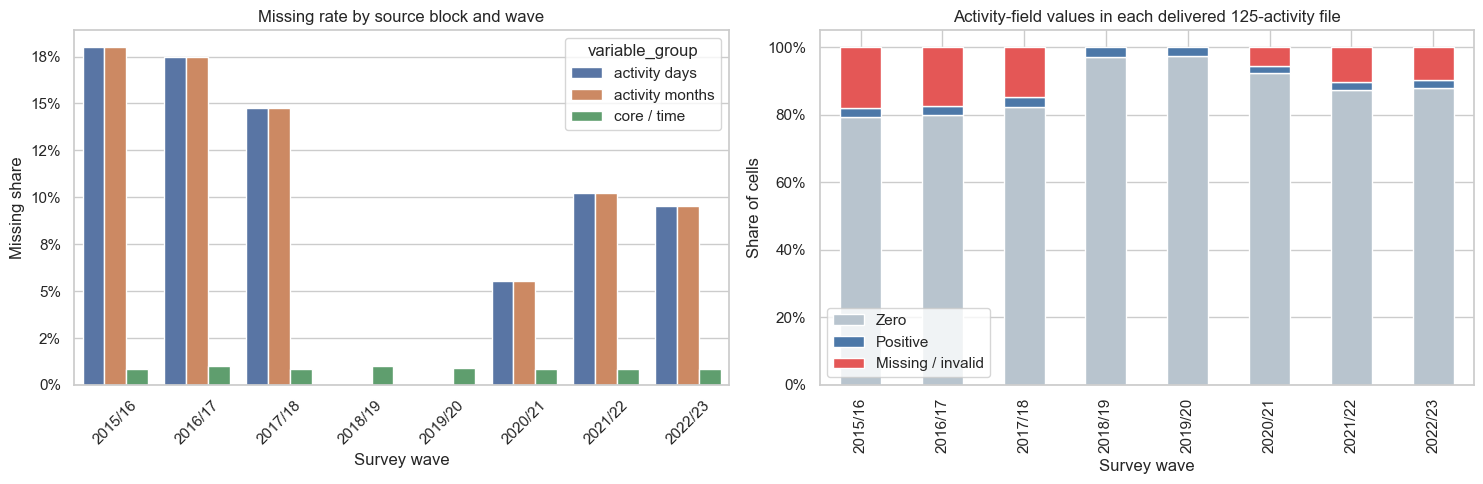

In [10]:
# Show missingness by year and whether activity cells contain zero, positive or missing codes.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=group_missingness, x='survey_wave', y='missing_rate',
    hue='variable_group', ax=axes[0],
)
axes[0].set(title='Missing rate by source block and wave', xlabel='Survey wave', ylabel='Missing share')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')

activity_plot = activity_value_composition.pivot(
    index='survey_wave', columns='value_group', values='share'
)[['zero', 'positive', 'missing_or_invalid']]
activity_plot.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#B8C4CE', '#4C78A8', '#E45756'],
)
axes[1].set(title='Activity-field values in each delivered 125-activity file', xlabel='Survey wave', ylabel='Share of cells')
axes[1].yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
axes[1].legend(['Zero', 'Positive', 'Missing / invalid'], title='')
plt.tight_layout()
plt.show()

### What the missingness check means

2018/19 and 2019/20 contain only valid `0/1/2` activity codes in the supplied CSV files, so their zero activity-field missingness is not created by this notebook. The 2018/19 preparation notebook converted its listed raw missing codes before export. Complete upstream provenance is unavailable for 2019/20, so the defensible conclusion is limited to the supplied CSV—not the original survey `.sav` file.

The audit also shows why a blanket complete-case rule would be inappropriate: activity missingness differs by wave and can reflect routing. The next stage therefore keeps all source rows and records eligibility explicitly.

## 4. Combine respondents and define usable samples

All eight waves are now stacked into one respondent table. Outcomes, geography and weights are never imputed. A person is not deleted merely because an individual activity is missing; instead, every activity estimate later uses its own valid-response denominator.

This block standardises numeric codes, maps borough and Inner/Outer labels, creates a stable record key and adds separate annual and monthly/quarterly eligibility flags before forming the two estimation samples.

In [11]:
BASE_COLUMNS = [
    'mode', 'LA_2023', 'LondInOut', 'Age9', 'Disab3',
    'wt_final', 'wt_time', 'MEMS7GR_ALL',
]


def load_wave(wave):
    '''Load one wave, standardise numeric missing codes and retain every source row.'''
    header = headers[wave['wave_index']]
    month_source = next(column for column in header if column.lower() == 'month')
    usecols = BASE_COLUMNS + [month_source] + MONTHS_COLUMNS + DAYS_COLUMNS
    assert not (set(usecols) - set(header))

    frame = pd.read_csv(wave['path'], usecols=usecols, low_memory=False)
    frame = frame.rename(columns={month_source: 'month_index'})
    numeric_columns = BASE_COLUMNS + ['month_index'] + MONTHS_COLUMNS + DAYS_COLUMNS
    frame[numeric_columns] = frame[numeric_columns].apply(pd.to_numeric, errors='coerce')
    frame = frame.replace(SPSS_MISSING, np.nan)

    # A stable within-wave row number provides a unique audit key without claiming identity linkage.
    frame.insert(0, 'source_row', np.arange(1, len(frame) + 1))
    frame.insert(0, 'source_file', wave['path'].name)
    frame.insert(0, 'survey_wave', wave['survey_wave'])
    frame.insert(0, 'year', wave['wave_index'])
    frame.insert(0, 'respondent_record_id', [f"Y{wave['wave_index']}_{row:06d}" for row in frame['source_row']])
    return frame


# Decode borough labels once, then map them onto the eight-wave respondent table.
lookup = pd.read_csv(LOOKUP_PATH, low_memory=False)
lookup['Code'] = pd.to_numeric(lookup['Code'], errors='coerce')
la_lookup = (
    lookup[lookup['year'].eq(8) & lookup['Variable'].eq('LA_2023')][['Code', 'CodeLabel']]
    .dropna().drop_duplicates('Code')
)
la_lookup['gss_code'] = la_lookup['CodeLabel'].str.split().str[0]
la_lookup['borough'] = la_lookup['CodeLabel'].str.split(n=1).str[1]

respondents = pd.concat([load_wave(wave) for wave in waves], ignore_index=True)
respondents['borough'] = respondents['LA_2023'].map(la_lookup.set_index('Code')['borough'])
respondents['gss_code'] = respondents['LA_2023'].map(la_lookup.set_index('Code')['gss_code'])
respondents['inner_outer'] = respondents['LondInOut'].map(AREA_LABELS)

# Eligibility flags are cumulative and remain in the delivered respondent table.
respondents['valid_activity_level'] = respondents['MEMS7GR_ALL'].isin([0, 1, 2])
respondents['valid_geography'] = (
    respondents['LondInOut'].isin([1, 2])
    & respondents['borough'].notna()
    & respondents['LA_2023'].ne(CITY_OF_LONDON_LA2023)
)
respondents['positive_annual_weight'] = respondents['wt_final'].gt(0)
respondents['valid_month'] = respondents['month_index'].isin(range(1, 97))
respondents['positive_monthly_weight'] = respondents['wt_time'].gt(0)
respondents['annual_analysis_eligible'] = (
    respondents['valid_activity_level'] & respondents['valid_geography']
    & respondents['positive_annual_weight']
)
respondents['monthly_analysis_eligible'] = (
    respondents['valid_activity_level'] & respondents['valid_geography']
    & respondents['valid_month'] & respondents['positive_monthly_weight']
)
respondents['activity_items_observed'] = respondents[MONTHS_COLUMNS + DAYS_COLUMNS].notna().sum(axis=1)
respondents['activity_item_missing_rate'] = 1 - respondents['activity_items_observed'] / (2 * len(ACTIVITY_SUFFIXES))
respondents['high_activity_missingness'] = respondents['activity_item_missing_rate'].gt(0.50)

annual_respondents = respondents.loc[respondents['annual_analysis_eligible']].copy()
monthly_respondents = respondents.loc[respondents['monthly_analysis_eligible']].copy()
assert respondents['respondent_record_id'].is_unique
assert len(annual_respondents) == 135497
assert len(monthly_respondents) == 134916
assert set(monthly_respondents['month_index'].astype(int)) == set(range(1, 97))
assert annual_respondents['borough'].nunique() == monthly_respondents['borough'].nunique() == 32

cleaning_flow = respondents.groupby(['year', 'survey_wave'], as_index=False).agg(
    source_rows=('respondent_record_id', 'size'),
    valid_activity=('valid_activity_level', 'sum'),
    valid_geography=('valid_geography', 'sum'),
    annual_eligible=('annual_analysis_eligible', 'sum'),
    monthly_eligible=('monthly_analysis_eligible', 'sum'),
    high_activity_missingness=('high_activity_missingness', 'sum'),
)
display(cleaning_flow)

C:\Users\eik\AppData\Local\Temp\ipykernel_21392\1609940277.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  respondents['borough'] = respondents['LA_2023'].map(la_lookup.set_index('Code')['borough'])
C:\Users\eik\AppData\Local\Temp\ipykernel_21392\1609940277.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  respondents['gss_code'] = respondents['LA_2023'].map(la_lookup.set_index('Code')['gss_code'])
C:\Users\eik\AppData\Local\Temp\ipykernel_21392\1609940277.py:42: PerformanceWarning: DataFrame is highly fragmented.  This 

,year,survey_wave,source_rows,valid_activity,valid_geography,annual_eligible,monthly_eligible,high_activity_missingness
0,1,2015/16,19620,19620,19620,19620,19620,0
1,2,2016/17,19248,19248,19248,19248,18987,0
2,3,2017/18,15967,15967,15967,15967,15961,0
3,4,2018/19,15889,15889,15889,15889,15698,0
4,5,2019/20,16091,16091,16091,16091,16002,0
5,6,2020/21,16028,16028,16028,16028,15994,0
6,7,2021/22,16139,16139,16139,16139,16139,0
7,8,2022/23,16515,16515,16515,16515,16515,0


The retention chart makes those rules visible, after which the complete flagged respondent table is written once for any future individual-level analysis.

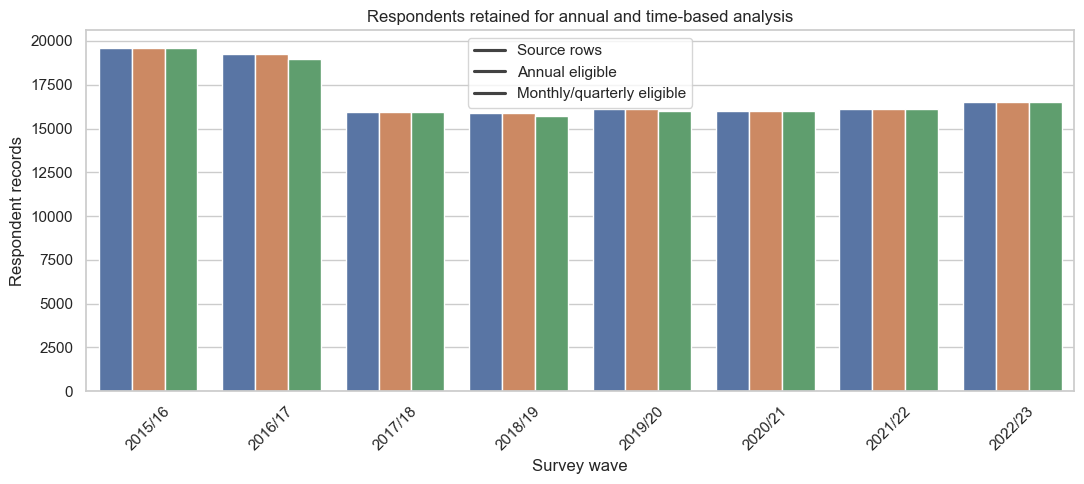

**Integrated respondent table:** 135,497 rows, 275 columns; 134,916 rows are eligible for monthly/quarterly estimates.

In [12]:
# Compare source rows with the two samples actually used for estimation.
flow_plot = cleaning_flow.melt(
    id_vars='survey_wave',
    value_vars=['source_rows', 'annual_eligible', 'monthly_eligible'],
    var_name='sample', value_name='respondents',
)
plt.figure(figsize=(11, 5))
sns.barplot(data=flow_plot, x='survey_wave', y='respondents', hue='sample')
plt.title('Respondents retained for annual and time-based analysis')
plt.xlabel('Survey wave')
plt.ylabel('Respondent records')
plt.xticks(rotation=45)
plt.legend(['Source rows', 'Annual eligible', 'Monthly/quarterly eligible'], title='')
plt.tight_layout()
plt.show()

# CSV is larger than Parquet but keeps the output contract simple and universal.
respondents.to_csv(OUTPUTS['respondents'], index=False, encoding='utf-8-sig')
display(Markdown(
    f"**Integrated respondent table:** {len(respondents):,} rows, "
    f"{respondents.shape[1]:,} columns; {len(monthly_respondents):,} rows are "
    "eligible for monthly/quarterly estimates."
))

### Respondent result

All **135,497** records are usable for annual estimates. **134,916** are usable for monthly and quarterly estimates; the other 581 remain in the respondent CSV but are not used with the time weight. With the sample fixed, aggregation can proceed without any later notebook changing who is included.

## 5. Convert respondent records into multilevel panels

The same aggregation logic is used for every time and geographic level. Annual estimates use `wt_final`; monthly and quarterly estimates use `wt_time`. The three activity outcomes are required to sum to one, while each detailed activity rate uses only valid responses for that activity.

This block defines the shared weighted summaries, including the three activity outcomes, survey-composition controls, detailed activity rates and `effective_n` quality metadata.

In [13]:
# Execute this preparation step.
def kish_effective_n(weights):
    """Calculate Kish effective sample size from positive survey weights."""
    weights = np.asarray(weights, dtype=float)
    return float(weights.sum() ** 2 / np.square(weights).sum())


def weighted_binary_share(values, weights, valid_codes, positive_codes):
    """Estimate a weighted binary share using only explicitly valid response codes."""
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isin(values, valid_codes) & np.isfinite(weights) & (weights > 0)
    if not valid.any():
        return np.nan
    return float(np.average(np.isin(values[valid], positive_codes), weights=weights[valid]))


def weighted_rate_vector(values, weights, valid_codes, positive_rule):
    """Calculate many activity rates at once, each with its own available-case denominator."""
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)[:, None]
    valid = np.isin(values, valid_codes)
    denominator = np.sum(valid * weights, axis=0)
    numerator = np.sum((positive_rule(values) & valid) * weights, axis=0)
    return np.divide(
        numerator,
        denominator,
        out=np.full(values.shape[1], np.nan, dtype=float),
        where=denominator > 0,
    )


def summarise_group(group, weight_column):
    """Produce outcomes, composition measures and 372 activity rates for one survey group."""
    weights = group[weight_column].to_numpy(float)
    total = weights.sum()
    row = {
        'effective_n': kish_effective_n(weights),
        'inactive_rate': float(weights[group['MEMS7GR_ALL'].eq(0).to_numpy()].sum() / total),
        'fairly_active_rate': float(weights[group['MEMS7GR_ALL'].eq(1).to_numpy()].sum() / total),
        'active_rate': float(weights[group['MEMS7GR_ALL'].eq(2).to_numpy()].sum() / total),
        'older_adult_rate': weighted_binary_share(group['Age9'], weights, range(2, 10), [7, 8, 9]),
        'limiting_disability_rate': weighted_binary_share(
            group['Disab3'], weights, [1, 2, 3], [1]
        ),
        'online_response_rate': weighted_binary_share(group['mode'], weights, [1, 2], [1]),
    }
    months12_rates = weighted_rate_vector(
        group[MONTHS_COLUMNS], weights, [0, 1], lambda values: values == 1
    )
    days_any_rates = weighted_rate_vector(
        group[DAYS_COLUMNS], weights, [0, 1, 2], lambda values: values >= 1
    )
    days_2plus_rates = weighted_rate_vector(
        group[DAYS_COLUMNS], weights, [0, 1, 2], lambda values: values == 2
    )
    row.update(dict(zip(MONTHS12_RATE_COLUMNS, months12_rates)))
    row.update(dict(zip(DAYS_ANY_RATE_COLUMNS, days_any_rates)))
    row.update(dict(zip(DAYS_2PLUS_RATE_COLUMNS, days_2plus_rates)))
    return row


def aggregate_panel(frame, group_columns, weight_column):
    """Apply the common weighted summary to every requested time–geography group."""
    rows = []
    grouper = group_columns[0] if len(group_columns) == 1 else group_columns
    for keys, group in frame.groupby(grouper, observed=True, sort=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        row = dict(zip(group_columns, keys))
        row.update(summarise_group(group, weight_column))
        rows.append(row)
    return pd.DataFrame(rows)

### 5.1 Annual panels

Annual respondent estimates are produced first because they have the strongest sample support. Borough external context is joined by matching year, then aggregated consistently to Inner/Outer London and London.

This block creates annual rows for all three geographic levels and joins the corresponding annual population, migration, earnings and crime measures.

In [14]:
# Execute this preparation step.
london_annual = aggregate_panel(annual_respondents, ['year', 'survey_wave'], 'wt_final')
london_annual['geography_level'] = 'London'
london_annual['geography_code'] = 'LONDON_32'
london_annual['geography_name'] = 'London excluding City of London'

area_annual = aggregate_panel(
    annual_respondents, ['year', 'survey_wave', 'LondInOut'], 'wt_final'
)
area_annual['inner_outer'] = area_annual['LondInOut'].map(AREA_LABELS)
area_annual['geography_level'] = 'InnerOuter'
area_annual['geography_code'] = area_annual['LondInOut'].map(AREA_CODES)
area_annual['geography_name'] = area_annual['inner_outer']

borough_annual = aggregate_panel(
    annual_respondents, ['year', 'survey_wave', 'LA_2023'], 'wt_final'
).merge(
    la_lookup[['Code', 'gss_code', 'borough']],
    left_on='LA_2023', right_on='Code', validate='many_to_one'
)
borough_annual['inner_outer'] = borough_annual['LA_2023'].map(
    annual_respondents.drop_duplicates('LA_2023').set_index('LA_2023')['inner_outer']
)
borough_annual['geography_level'] = 'Borough'
borough_annual['geography_code'] = borough_annual['gss_code']
borough_annual['geography_name'] = borough_annual['borough']

borough_reference = borough_annual[
    ['geography_code', 'geography_name', 'inner_outer']
].drop_duplicates()
borough_external_geo = borough_external_year.merge(
    borough_reference, on=['geography_code', 'geography_name'], validate='many_to_one'
)
crime_annual_counts = crime_counts.groupby(
    ['BoroughName', 'year', 'survey_wave'], as_index=False
)[CRIME_COUNT_COLUMNS].sum()
borough_annual_context = crime_annual_counts.merge(
    borough_external_geo.assign(year=lambda frame: frame['calendar_year'] - 2015),
    left_on=['BoroughName', 'year'],
    right_on=['geography_name', 'year'],
    validate='one_to_one',
)
borough_annual_context['context_reference_year'] = borough_annual_context['calendar_year']
borough_annual_context = add_context_rates(borough_annual_context)
area_annual_context = aggregate_context(
    borough_annual_context, ['year', 'survey_wave', 'inner_outer']
)
area_annual_context['context_reference_year'] = area_annual_context['year'] + 2015
london_annual_context = aggregate_context(borough_annual_context, ['year', 'survey_wave'])
london_annual_context['context_reference_year'] = london_annual_context['year'] + 2015

london_annual = london_annual.merge(
    compact_context(london_annual_context), on=['year', 'survey_wave'], validate='one_to_one'
)
area_annual = area_annual.merge(
    compact_context(area_annual_context),
    on=['year', 'survey_wave', 'inner_outer'],
    validate='one_to_one',
)
borough_annual = borough_annual.merge(
    compact_context(borough_annual_context),
    on=['year', 'survey_wave', 'geography_code', 'geography_name', 'inner_outer'],
    validate='one_to_one',
)

Before creating finer-frequency panels, the London annual series provides a simple plausibility check: all three outcome categories are shown together so both trend and composition can be read at a glance.

The following chart displays the weighted London composition across the eight survey waves; it is a check of the integrated outcome rather than a separate analytical result.

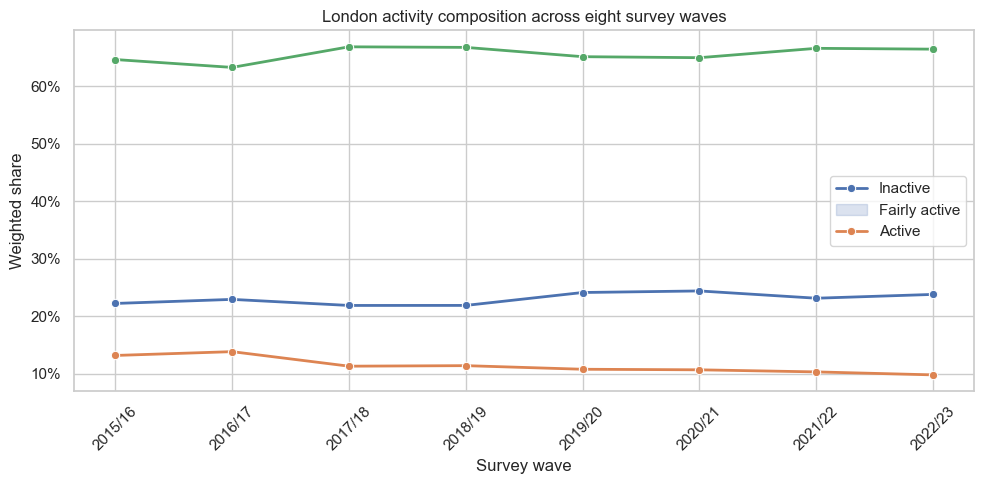

In [15]:
# Plot all three London activity categories so the composition remains visible.
annual_long = london_annual.melt(
    id_vars='survey_wave', value_vars=OUTCOME_COLUMNS,
    var_name='activity_level', value_name='share',
)
plt.figure(figsize=(10, 5))
sns.lineplot(data=annual_long, x='survey_wave', y='share', hue='activity_level', marker='o', linewidth=2)
plt.title('London activity composition across eight survey waves')
plt.xlabel('Survey wave')
plt.ylabel('Weighted share')
plt.gca().yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.xticks(rotation=45)
plt.legend(['Inactive', 'Fairly active', 'Active'], title='')
plt.tight_layout()
plt.show()

### 5.2 Monthly and quarterly panels

The same respondents are now grouped at finer time scales. Quarterly estimates are calculated directly from respondent records with `wt_time`, not by averaging monthly percentages. This preserves the survey weighting and gives each frequency a clearly defined target.

This block builds London, Inner/Outer and borough panels for all 96 months and 32 quarters, then attaches external context at the matching time scale.

In [16]:
# Execute this preparation step.
borough_month_context = crime_counts.merge(
    borough_external_geo,
    left_on=['BoroughName', 'calendar_year'],
    right_on=['geography_name', 'calendar_year'],
    validate='many_to_one',
)
borough_month_context['context_reference_year'] = borough_month_context['calendar_year']
borough_month_context = add_context_rates(borough_month_context)
area_month_context = aggregate_context(
    borough_month_context, ['month_index', 'period_start', 'calendar_year', 'inner_outer']
)
area_month_context['context_reference_year'] = area_month_context['calendar_year']
london_month_context = aggregate_context(
    borough_month_context, ['month_index', 'period_start', 'calendar_year']
)
london_month_context['context_reference_year'] = london_month_context['calendar_year']

london_estimates = aggregate_panel(monthly_respondents, ['month_index'], 'wt_time')
london_monthly = time_reference.merge(london_estimates, on='month_index', how='left', validate='one_to_one')
london_monthly['geography_level'] = 'London'
london_monthly['geography_code'] = 'LONDON_32'
london_monthly['geography_name'] = 'London excluding City of London'
london_monthly = london_monthly.merge(
    compact_context(london_month_context),
    on=['month_index', 'period_start', 'calendar_year'], validate='one_to_one',
)

area_reference = pd.DataFrame({
    'LondInOut': [1, 2],
    'inner_outer': [AREA_LABELS[1], AREA_LABELS[2]],
    'geography_code': [AREA_CODES[1], AREA_CODES[2]],
})
area_estimates = aggregate_panel(monthly_respondents, ['month_index', 'LondInOut'], 'wt_time')
area_monthly = time_reference.merge(area_reference, how='cross').merge(
    area_estimates, on=['month_index', 'LondInOut'], how='left', validate='one_to_one'
)
area_monthly['geography_level'] = 'InnerOuter'
area_monthly['geography_name'] = area_monthly['inner_outer']
area_monthly = area_monthly.merge(
    compact_context(area_month_context),
    on=['month_index', 'period_start', 'calendar_year', 'inner_outer'], validate='one_to_one',
)

borough_estimates = aggregate_panel(monthly_respondents, ['month_index', 'LA_2023'], 'wt_time')
borough_monthly = time_reference.merge(
    annual_respondents[['LA_2023', 'gss_code', 'borough', 'inner_outer']].drop_duplicates(),
    how='cross',
).merge(
    borough_estimates, on=['month_index', 'LA_2023'], how='left', validate='one_to_one'
)
borough_monthly['geography_level'] = 'Borough'
borough_monthly['geography_code'] = borough_monthly['gss_code']
borough_monthly['geography_name'] = borough_monthly['borough']
borough_monthly = borough_monthly.merge(
    compact_context(borough_month_context).drop(
        columns=['year', 'survey_wave', 'quarter_index'], errors='ignore'
    ),
    on=['month_index', 'period_start', 'calendar_year',
        'geography_code', 'geography_name', 'inner_outer'],
    validate='one_to_one',
)

monthly_respondents['quarter_index'] = ((monthly_respondents['month_index'] - 1) // 3 + 1).astype(int)
quarter_reference = time_reference.groupby('quarter_index', as_index=False).agg(
    year=('year', 'first'), survey_wave=('survey_wave', 'first'),
    quarter_of_wave=('month_of_wave', lambda values: int((values.min() - 1) // 3 + 1)),
    quarter_start=('period_start', 'min'), quarter_end=('period_start', 'max'),
)

quarter_context_rows = []
for (borough, quarter_index), group in borough_month_context.groupby(
    ['geography_name', 'quarter_index'], sort=True
):
    row = {
        'geography_name': borough, 'quarter_index': quarter_index,
        'geography_code': group['geography_code'].iloc[0],
        'inner_outer': group['inner_outer'].iloc[0],
        'context_reference_year': group.sort_values('period_start')['calendar_year'].iloc[-1],
        'total_population': group['total_population'].mean(),
        'adult_population': group['adult_population'].mean(),
        'age_16_34_population': group['age_16_34_population'].mean(),
        'age_65_plus_population': group['age_65_plus_population'].mean(),
        'female_adult_population': group['female_adult_population'].mean(),
        'net_migration': group['net_migration'].mean(),
        'median_weekly_earnings_gbp': np.average(
            group['median_weekly_earnings_gbp'], weights=group['adult_population']
        ),
        'earnings_relative_to_london': np.average(
            group['earnings_relative_to_london'], weights=group['adult_population']
        ),
        'earnings_confidence_pct': np.average(
            group['earnings_confidence_pct'], weights=group['adult_population']
        ),
    }
    for count_column in CRIME_COUNT_COLUMNS:
        row[count_column] = group[count_column].sum()
    quarter_context_rows.append(row)
borough_quarter_context = add_context_rates(pd.DataFrame(quarter_context_rows))
area_quarter_context = aggregate_context(
    borough_quarter_context, ['quarter_index', 'inner_outer']
).merge(
    quarter_reference[['quarter_index', 'quarter_end']], on='quarter_index', validate='many_to_one'
)
area_quarter_context['context_reference_year'] = area_quarter_context['quarter_end'].dt.year
london_quarter_context = aggregate_context(borough_quarter_context, ['quarter_index']).merge(
    quarter_reference[['quarter_index', 'quarter_end']], on='quarter_index', validate='one_to_one'
)
london_quarter_context['context_reference_year'] = london_quarter_context['quarter_end'].dt.year

london_quarter_estimates = aggregate_panel(monthly_respondents, ['quarter_index'], 'wt_time')
london_quarterly = quarter_reference.merge(
    london_quarter_estimates, on='quarter_index', how='left', validate='one_to_one'
)
london_quarterly['geography_level'] = 'London'
london_quarterly['geography_code'] = 'LONDON_32'
london_quarterly['geography_name'] = 'London excluding City of London'
london_quarterly = london_quarterly.merge(
    compact_context(london_quarter_context).drop(columns='quarter_end', errors='ignore'),
    on='quarter_index', validate='one_to_one',
)

area_quarter_estimates = aggregate_panel(
    monthly_respondents, ['quarter_index', 'LondInOut'], 'wt_time'
)
area_quarterly = quarter_reference.merge(area_reference, how='cross').merge(
    area_quarter_estimates, on=['quarter_index', 'LondInOut'], how='left', validate='one_to_one'
)
area_quarterly['geography_level'] = 'InnerOuter'
area_quarterly['geography_name'] = area_quarterly['inner_outer']
area_quarterly = area_quarterly.merge(
    compact_context(area_quarter_context).drop(columns='quarter_end', errors='ignore'),
    on=['quarter_index', 'inner_outer'], validate='one_to_one',
)

borough_quarter_estimates = aggregate_panel(
    monthly_respondents, ['quarter_index', 'LA_2023'], 'wt_time'
)
borough_quarterly = quarter_reference.merge(
    annual_respondents[['LA_2023', 'gss_code', 'borough', 'inner_outer']].drop_duplicates(),
    how='cross',
).merge(
    borough_quarter_estimates, on=['quarter_index', 'LA_2023'], how='left', validate='one_to_one'
)
borough_quarterly['geography_level'] = 'Borough'
borough_quarterly['geography_code'] = borough_quarterly['gss_code']
borough_quarterly['geography_name'] = borough_quarterly['borough']
borough_quarterly = borough_quarterly.merge(
    compact_context(borough_quarter_context),
    on=['quarter_index', 'geography_code', 'geography_name', 'inner_outer'],
    validate='one_to_one',
)

Once all nine internal panels exist, their identifiers and measures are placed in a consistent column order. They can then be combined into one CSV per frequency without losing the `geography_level` distinction.

In [17]:
# Execute this preparation step.
TIME_ORDER = [
    'month_index', 'quarter_index', 'year', 'survey_wave', 'month_of_wave',
    'period_start', 'calendar_year',
]
QUARTER_TIME_ORDER = [
    'quarter_index', 'year', 'survey_wave', 'quarter_of_wave', 'quarter_start', 'quarter_end',
]
GEO_ORDER = ['geography_level', 'geography_code', 'geography_name']
MEASURE_ORDER = (
    QUALITY_COLUMNS + OUTCOME_COLUMNS + COMPOSITION_FEATURES + ACTIVITY_FEATURES
    + EXTERNAL_CONTEXT_COLUMNS + EXTERNAL_QUALITY_COLUMNS + ['context_reference_year']
)
ANNUAL_ORDER = ['year', 'survey_wave'] + GEO_ORDER
london_annual = london_annual[ANNUAL_ORDER + MEASURE_ORDER]
area_annual = area_annual[ANNUAL_ORDER + ['inner_outer'] + MEASURE_ORDER]
borough_annual = borough_annual[ANNUAL_ORDER + ['inner_outer'] + MEASURE_ORDER]
london_monthly = london_monthly[TIME_ORDER + GEO_ORDER + MEASURE_ORDER]
area_monthly = area_monthly[TIME_ORDER + GEO_ORDER + ['inner_outer'] + MEASURE_ORDER]
borough_monthly = borough_monthly[TIME_ORDER + GEO_ORDER + ['inner_outer'] + MEASURE_ORDER]
london_quarterly = london_quarterly[QUARTER_TIME_ORDER + GEO_ORDER + MEASURE_ORDER]
area_quarterly = area_quarterly[QUARTER_TIME_ORDER + GEO_ORDER + ['inner_outer'] + MEASURE_ORDER]
borough_quarterly = borough_quarterly[QUARTER_TIME_ORDER + GEO_ORDER + ['inner_outer'] + MEASURE_ORDER]

## 6. Check sample support and retain age detail

Complete grids alone do not guarantee equally reliable estimates. The notebook therefore checks both raw respondent counts and `effective_n` before export. These diagnostics explain where borough-month or borough-year estimates may be noisier; they are not extra predictors.

The next charts compare sample support across boroughs and waves and show whether survey weighting materially changes the Inner/Outer representation.

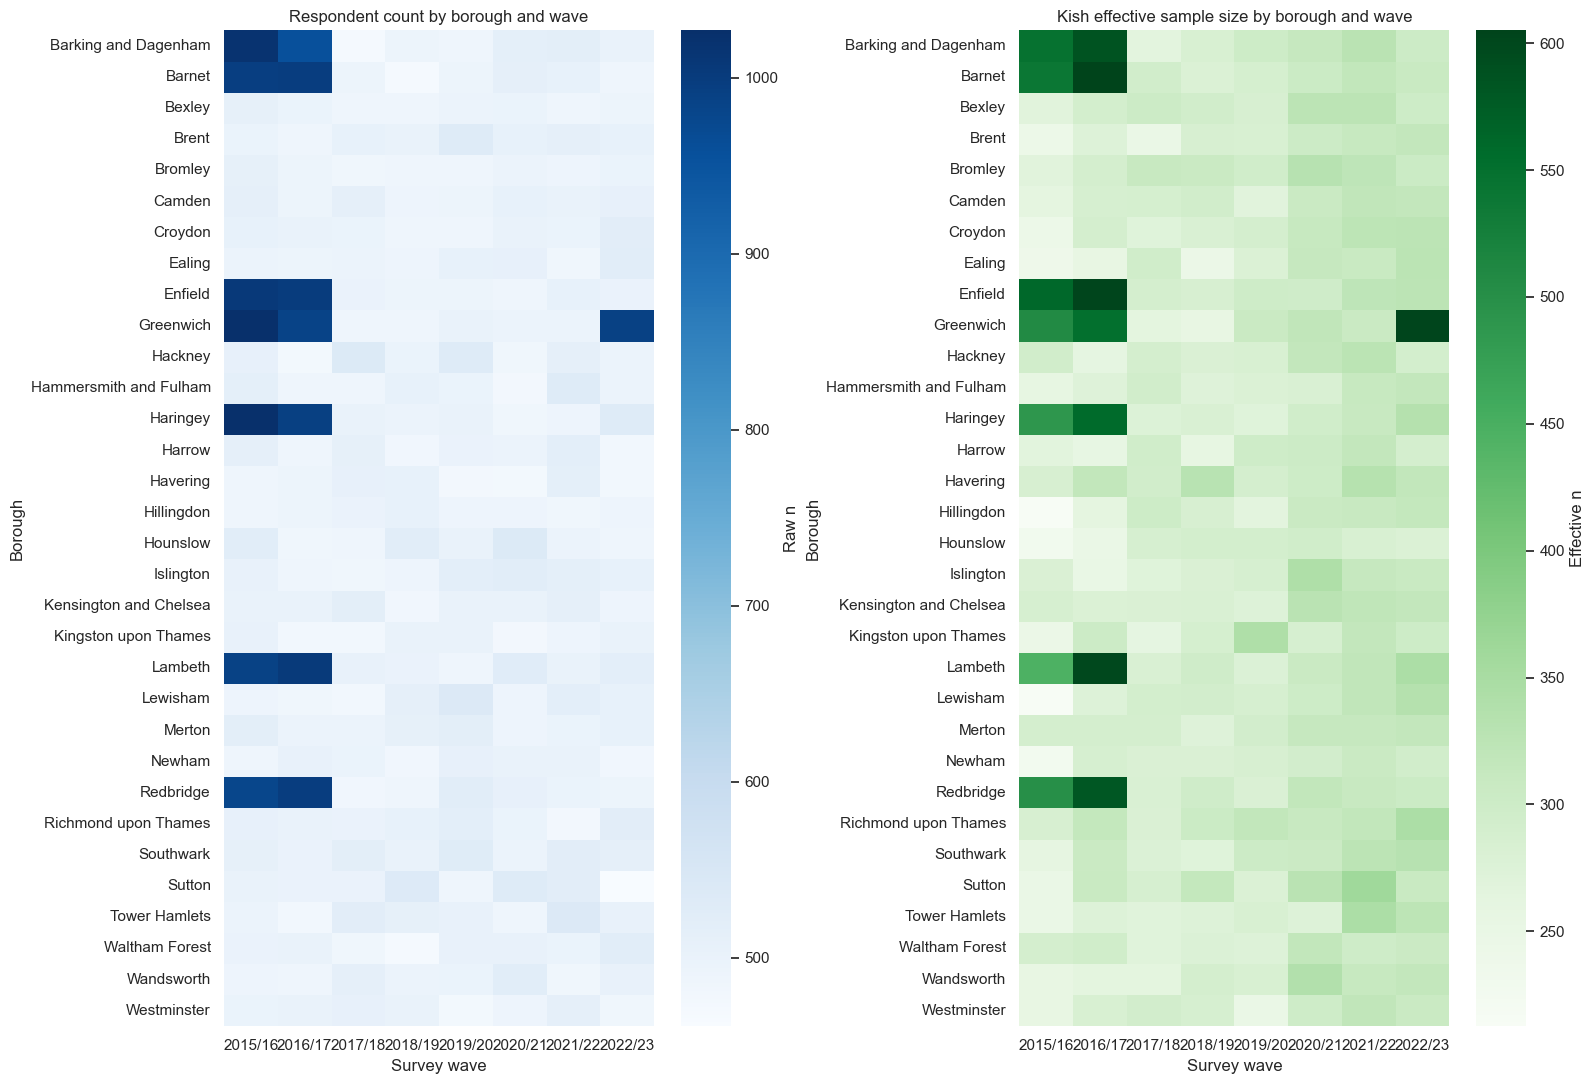

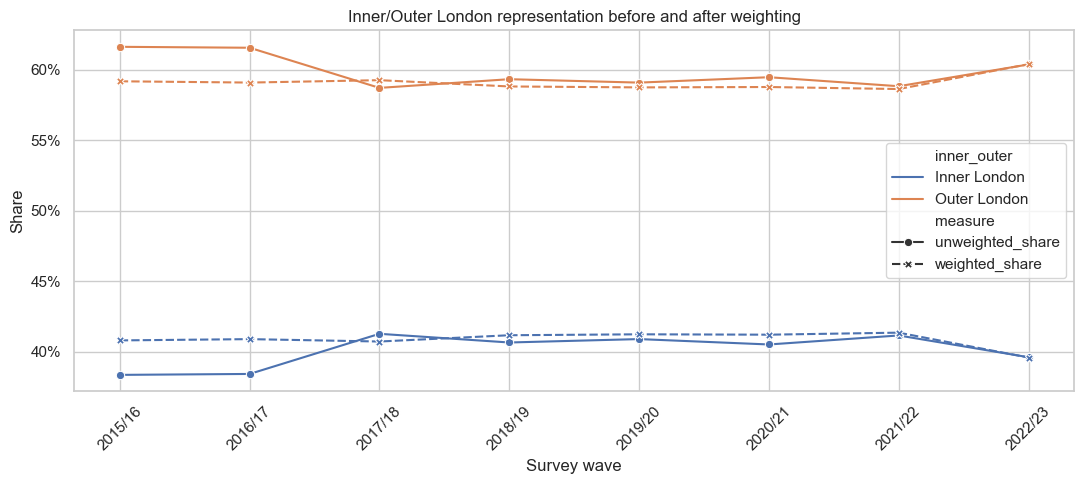

In [18]:
# Execute this preparation step.
borough_wave_n = annual_respondents.pivot_table(
    index='borough', columns='survey_wave', values='respondent_record_id', aggfunc='count'
)
borough_wave_neff = borough_annual.pivot(
    index='geography_name', columns='survey_wave', values='effective_n'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 11))
sns.heatmap(borough_wave_n, cmap='Blues', ax=axes[0], cbar_kws={'label': 'Raw n'})
axes[0].set(title='Respondent count by borough and wave', xlabel='Survey wave', ylabel='Borough')
sns.heatmap(borough_wave_neff, cmap='Greens', ax=axes[1], cbar_kws={'label': 'Effective n'})
axes[1].set(title='Kish effective sample size by borough and wave', xlabel='Survey wave', ylabel='Borough')
plt.tight_layout()
plt.show()

area_balance = annual_respondents.groupby(['survey_wave', 'inner_outer'], as_index=False).agg(
    respondent_n=('respondent_record_id', 'size'),
    weight_sum=('wt_final', 'sum'),
)
area_balance['unweighted_share'] = area_balance['respondent_n'] / area_balance.groupby('survey_wave')['respondent_n'].transform('sum')
area_balance['weighted_share'] = area_balance['weight_sum'] / area_balance.groupby('survey_wave')['weight_sum'].transform('sum')
area_balance_long = area_balance.melt(
    id_vars=['survey_wave', 'inner_outer'],
    value_vars=['unweighted_share', 'weighted_share'],
    var_name='measure', value_name='share',
)
plt.figure(figsize=(11, 5))
sns.lineplot(data=area_balance_long, x='survey_wave', y='share', hue='inner_outer', style='measure', markers=True)
plt.title('Inner/Outer London representation before and after weighting')
plt.xlabel('Survey wave')
plt.ylabel('Share')
plt.gca().yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sample-support result

Every borough is represented in every wave. Borough-wave raw samples range from **461 to 1,027**, while `effective_n` ranges from **212.6 to 605.0**. The panel is structurally balanced, but its precision is not identical across cells, so `effective_n` is retained as quality metadata for later uncertainty and prediction checks.

### 6.1 Age-specific annual evidence

The main annual panel already contains broad age-composition controls. A separate age table is still needed for age-specific activity rates and contribution decomposition because its key is `year × geography × age_band`; merging it directly into the main annual panel would duplicate every geography-year row four times.

Four stable adult groups—16–34, 35–54, 55–64 and 65+—are prepared at London, Inner/Outer and borough level. Survey activity rates use `wt_final`, and population shares use the matching ONS calendar year.

This block creates the four age-group activity compositions and attaches matching population shares, producing one consistent age table for the descriptive notebook without contaminating the forecasting panel keys.

In [19]:
# Execute this preparation step.
AGE_BANDS = ['16-34', '35-54', '55-64', '65+']
AGE_CODE_TO_BAND = {
    2: '16-34', 3: '16-34', 4: '35-54', 5: '35-54',
    6: '55-64', 7: '65+', 8: '65+', 9: '65+',
}
age_respondents = annual_respondents.loc[
    annual_respondents['Age9'].isin(AGE_CODE_TO_BAND)
].copy()
age_respondents['age_band'] = age_respondents['Age9'].map(AGE_CODE_TO_BAND)
age_respondents['calendar_year'] = 2015 + age_respondents['year']


def summarise_age_group(group):
    """Estimate weighted activity composition and effective n within one age group."""
    weights = group['wt_final'].to_numpy(float)
    total = weights.sum()
    row = {'respondent_n': len(group), 'effective_n': total**2 / np.square(weights).sum()}
    for code_value, target in zip([0, 1, 2], OUTCOME_COLUMNS):
        row[target] = weights[group['MEMS7GR_ALL'].eq(code_value).to_numpy()].sum() / total
    return pd.Series(row)


population_age = population_long.loc[population_long['age'].ge(16)].copy()
population_age['age_band'] = pd.cut(
    population_age['age'], bins=[15, 34, 54, 64, np.inf], labels=AGE_BANDS, right=True
)
population_age = population_age.groupby(
    ['ladcode23', 'laname23', 'calendar_year', 'age_band'], observed=True, as_index=False
)['population'].sum()
population_age['adult_population'] = population_age.groupby(
    ['ladcode23', 'calendar_year']
)['population'].transform('sum')
population_age['population_share'] = population_age['population'] / population_age['adult_population']

age_borough_annual = age_respondents.groupby(
    ['year', 'survey_wave', 'calendar_year', 'gss_code', 'borough', 'inner_outer', 'age_band'],
    observed=True, sort=True,
).apply(summarise_age_group, include_groups=False).reset_index().rename(
    columns={'gss_code': 'geography_code', 'borough': 'geography_name'}
)
age_borough_annual = age_borough_annual.merge(
    population_age[['ladcode23', 'calendar_year', 'age_band', 'population', 'population_share']],
    left_on=['geography_code', 'calendar_year', 'age_band'],
    right_on=['ladcode23', 'calendar_year', 'age_band'], validate='one_to_one',
).drop(columns='ladcode23')


def aggregate_age_level(group_columns, geography_level):
    """Combine survey age estimates with matching ONS population shares at one geography level."""
    survey = age_respondents.groupby(group_columns + ['age_band'], observed=True, sort=True).apply(
        summarise_age_group, include_groups=False
    ).reset_index()
    population_keys = [column for column in group_columns if column in ['year', 'calendar_year', 'inner_outer']]
    population_base = age_borough_annual.copy()
    population = population_base.groupby(population_keys + ['age_band'], observed=True, as_index=False)[
        'population'
    ].sum()
    population['population_share'] = population['population'] / population.groupby(population_keys)[
        'population'
    ].transform('sum')
    result = survey.merge(population, on=population_keys + ['age_band'], validate='one_to_one')
    result['geography_level'] = geography_level
    return result


age_london_annual = aggregate_age_level(
    ['year', 'survey_wave', 'calendar_year'], 'London'
)
age_london_annual['geography_code'] = 'LONDON_32'
age_london_annual['geography_name'] = 'London excluding City of London'
age_area_annual = aggregate_age_level(
    ['year', 'survey_wave', 'calendar_year', 'inner_outer'], 'InnerOuter'
)
age_area_annual['geography_code'] = age_area_annual['inner_outer'].map(
    {'Inner London': AREA_CODES[1], 'Outer London': AREA_CODES[2]}
)
age_area_annual['geography_name'] = age_area_annual['inner_outer']

age_borough_annual['geography_level'] = 'Borough'

assert len(age_london_annual) == 8 * 4
assert len(age_area_annual) == 2 * 8 * 4
assert len(age_borough_annual) == 32 * 8 * 4

## 7. Validate once, then hand off to analysis

The final stage checks dimensions, unique keys, geography counts, valid ranges, positive `effective_n` and the requirement that inactive, fairly active and active sum to one. Only after these assertions pass are the five CSV files written.

This block validates the nine internal level-frequency panels, combines them into one annual, quarterly and monthly file, writes the respondent and age files, and displays the final row counts.

In [20]:
def validate_panel(panel, keys, expected_rows, expected_geographies, missing_rows=0):
    '''Check the dimensions, keys, ranges and three-part outcome composition.'''
    assert len(panel) == expected_rows
    assert not panel.duplicated(keys).any()
    assert panel['geography_code'].nunique() == expected_geographies
    observed_mask = panel[OUTCOME_COLUMNS].notna().all(axis=1)
    assert int((~observed_mask).sum()) == missing_rows
    observed = panel.loc[observed_mask]
    assert observed[OUTCOME_COLUMNS + COMPOSITION_FEATURES].apply(
        lambda column: column.between(0, 1)
    ).all().all()
    assert np.allclose(observed[OUTCOME_COLUMNS].sum(axis=1), 1, atol=1e-10)
    assert observed['effective_n'].gt(0).all()


# Validate the nine internal panels before combining them by frequency.
panels = {
    'london_annual': london_annual, 'area_annual': area_annual, 'borough_annual': borough_annual,
    'london_quarterly': london_quarterly, 'area_quarterly': area_quarterly,
    'borough_quarterly': borough_quarterly,
    'london_monthly': london_monthly, 'area_monthly': area_monthly,
    'borough_monthly': borough_monthly,
}
expectations = {
    'london_annual': (['year'], 8, 1, 0),
    'area_annual': (['year', 'geography_code'], 16, 2, 0),
    'borough_annual': (['year', 'geography_code'], 256, 32, 0),
    'london_quarterly': (['quarter_index'], 32, 1, 0),
    'area_quarterly': (['quarter_index', 'geography_code'], 64, 2, 0),
    'borough_quarterly': (['quarter_index', 'geography_code'], 1024, 32, 0),
    'london_monthly': (['month_index'], 96, 1, 0),
    'area_monthly': (['month_index', 'geography_code'], 192, 2, 0),
    'borough_monthly': (['month_index', 'geography_code'], 3072, 32, 1),
}
for name, panel in panels.items():
    validate_panel(panel, *expectations[name])

# One file per frequency is enough; geography_level recreates the nine analysis tasks.
combined_panels = {
    'annual': pd.concat([london_annual, area_annual, borough_annual], ignore_index=True, sort=False),
    'quarterly': pd.concat([london_quarterly, area_quarterly, borough_quarterly], ignore_index=True, sort=False),
    'monthly': pd.concat([london_monthly, area_monthly, borough_monthly], ignore_index=True, sort=False),
}
for frequency, frame in combined_panels.items():
    frame.to_csv(OUTPUTS[frequency], index=False, encoding='utf-8-sig')

age_annual = pd.concat(
    [age_london_annual, age_area_annual, age_borough_annual],
    ignore_index=True, sort=False,
)
age_annual.to_csv(OUTPUTS['age_annual'], index=False, encoding='utf-8-sig')

output_summary = pd.DataFrame([
    {'file': path.name, 'rows': len(respondents) if name == 'respondents' else
     len(age_annual) if name == 'age_annual' else len(combined_panels[name])}
    for name, path in OUTPUTS.items()
])
display(output_summary)

,file,rows
0,q1_respondents_8wave.csv,135497
1,q1_annual.csv,280
2,q1_quarterly.csv,1120
3,q1_monthly.csv,3360
4,q1_age_annual.csv,1120


### Final data contract

| File | Unit of observation | Used for |
|---|---|---|
| `q1_respondents_8wave.csv` | one supplied respondent record | individual-level checks and future extensions |
| `q1_annual.csv` | year × geography | annual description, clustering and forecasting |
| `q1_quarterly.csv` | quarter × geography | quarterly description and forecasting |
| `q1_monthly.csv` | month × geography | monthly description and forecasting |
| `q1_age_annual.csv` | year × geography × age group | annual age trends and contribution decomposition |

`geography_level` separates London, Inner/Outer and borough rows inside the three frequency files. Downstream notebooks should treat these files as read-only so that cleaning and sample definitions remain identical throughout the project.